<img src="https://github.com/lid-ufpa/genial/blob/main/assets/genial-logo-banner-dark.png?raw=true" style="width:100%; height:auto;">

# **Aula 2 - Algoritmos Genéticos (AG's)**


In [ ]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2.1 Introdução

Algoritmos Genéticos (AGs) são uma classe de algoritmos de busca e otimização inspirados pelo processo de seleção natural e evolução biológica. Propostos por John Holland na década de 1970, eles imitam os princípios da genética e da sobrevivência do mais apto para encontrar soluções aproximadas para problemas complexos, especialmente aqueles onde os métodos tradicionais de otimização falham ou são muito lentos.

A ideia central é evoluir uma população de soluções candidatas ao longo de várias gerações. A cada geração, os indivíduos mais "aptos" (as melhores soluções) têm maior probabilidade de serem selecionados para se reproduzir e transmitir suas características para a próxima geração. Através de operadores genéticos como cruzamento e mutação, novas soluções são criadas, explorando o espaço de busca de forma eficiente e convergindo, idealmente, para uma solução ótima ou próxima da ótima.

Eles são particularmente úteis em problemas de:

- Otimização (e.g., Problema do Caixeiro Viajante, Problema da Mochila).
- Busca em espaços de grande dimensão.
- Aprendizado de máquina (e.g., ajuste de hiperparâmetros, seleção de features).
- Design e engenharia.

AGs diferem de métodos tradicionais em quatro pontos:

1. AGs trabalham com uma codificação do conjunto de parâmetros, e não diretamente com os parâmetros.
2. AGs buscam em uma população de pontos, não em um único ponto.
3. AGs usam somente informação da função objetivo, sem necessitar de derivadas ou outro conhecimento auxiliar.
4. AGs usam regras de transição probabilísticas, ao invés de regras determinísticas.

---

## 2.2 Estrutura de um Algoritmo Genético

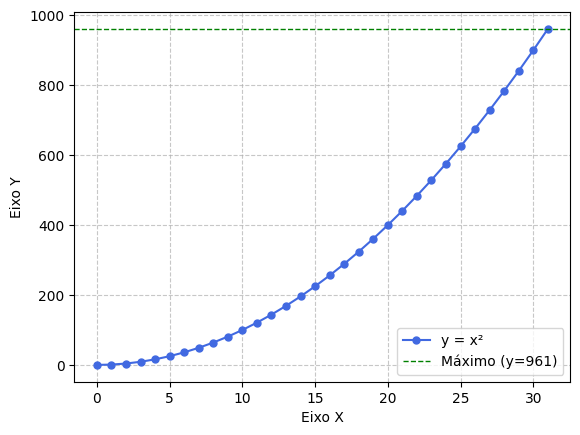

In [15]:
x = [i for i in range(32)]
y = [i**2 for i in x]

plt.plot(x, y, marker='o', linestyle='-', color="royalblue", markersize=5, label="y = x²")
plt.axhline(max(y), color='green', linewidth=1, linestyle='--', label="Máximo (y=961)")
plt.xlabel("Eixo X")
plt.ylabel("Eixo Y")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### 2.2.1 Indivíduo (cromossomo)

Representa uma única solução candidata para o nosso problema.

In [ ]:
def dec_to_bin(x, bits=5):
    return format(x, f'0{bits}b')

cromossomo_19 = dec_to_bin(19)
cromossomo_19

'10011'

In [ ]:
def bin_to_dec(b):
    return int(b, 2)

x_19 = bin_to_dec(cromossomo_19)
x_19

19

### 2.2.2 Gene

É a unidade que compõe um indivíduo.

In [ ]:
for i, gene in enumerate(cromossomo_19):
    print(f"Gene na posição {i}: {gene}")

Gene na posição 0: 1
Gene na posição 1: 0
Gene na posição 2: 0
Gene na posição 3: 1
Gene na posição 4: 1


### 2.2.3 População

É o conjunto de indivíduos (soluções).

In [ ]:
random.seed(42)

In [ ]:
tamanho_populacao = 10

xs = [random.randint(0, 31) for _ in range(10)]
xs

[7, 1, 17, 15, 14, 8, 6, 5, 27, 2]

In [ ]:
populacao = []

for i in range(tamanho_populacao):
    cromossomo = dec_to_bin(xs[i])
    populacao.append(cromossomo)

populacao

['00111',
 '00001',
 '10001',
 '01111',
 '01110',
 '01000',
 '00110',
 '00101',
 '11011',
 '00010']

In [ ]:
# criando um DataFrame com as colunas x e cromossomo
df_populacao = pd.DataFrame({"x": xs, "Cromossomo": populacao})

# adicionando colunas para cada gene
for i in range(5):
    df_populacao[f"Gene_{i}"] = df_populacao["Cromossomo"].apply(lambda x: x[i])

df_populacao

,x,Cromossomo,Gene_0,Gene_1,Gene_2,Gene_3,Gene_4
0,7,00111,0,0,1,1,1
1,1,00001,0,0,0,0,1
2,17,10001,1,0,0,0,1
3,15,01111,0,1,1,1,1
4,14,01110,0,1,1,1,0
5,8,01000,0,1,0,0,0
6,6,00110,0,0,1,1,0
7,5,00101,0,0,1,0,1
8,27,11011,1,1,0,1,1
9,2,00010,0,0,0,1,0


### 2.2.4 Função de aptidão (_fitness_)

É a função que mede a "qualidade" de cada indivíduo. Ela atribui um valor a cada solução, indicando o quão boa ela é.

In [ ]:
def fitness(x):
    return x**2

In [ ]:
df_populacao["Fitness"] = df_populacao["x"].apply(fitness)
df_populacao

,x,Cromossomo,Gene_0,Gene_1,Gene_2,Gene_3,Gene_4,Fitness
0,7,00111,0,0,1,1,1,49
1,1,00001,0,0,0,0,1,1
2,17,10001,1,0,0,0,1,289
3,15,01111,0,1,1,1,1,225
4,14,01110,0,1,1,1,0,196
5,8,01000,0,1,0,0,0,64
6,6,00110,0,0,1,1,0,36
7,5,00101,0,0,1,0,1,25
8,27,11011,1,1,0,1,1,729
9,2,00010,0,0,0,1,0,4


In [ ]:
df_populacao = df_populacao.sort_values(by="Fitness", ascending=False).reset_index(drop=True)
df_populacao

,x,Cromossomo,Gene_0,Gene_1,Gene_2,Gene_3,Gene_4,Fitness
0,27,11011,1,1,0,1,1,729
1,17,10001,1,0,0,0,1,289
2,15,01111,0,1,1,1,1,225
3,14,01110,0,1,1,1,0,196
4,8,01000,0,1,0,0,0,64
5,7,00111,0,0,1,1,1,49
6,6,00110,0,0,1,1,0,36
7,5,00101,0,0,1,0,1,25
8,2,00010,0,0,0,1,0,4
9,1,00001,0,0,0,0,1,1


### 2.2.5 Geração

Representa cada iteração do algoritmo.

In [ ]:
df_top2 = df_populacao.iloc[:2]
df_top2

,x,Cromossomo,Gene_0,Gene_1,Gene_2,Gene_3,Gene_4,Fitness
0,27,11011,1,1,0,1,1,729
1,17,10001,1,0,0,0,1,289


In [ ]:
n_geracoes = 30

pop_history = []
top_cromossomos = []

for g in range(n_geracoes):
    # criando uma nova população e calculando o fitness
    xs = [random.randint(0, 31) for _ in range(10)]
    df_populacao = pd.DataFrame({"x": xs, "Cromossomo": [dec_to_bin(x) for x in xs]})
    df_populacao["Fitness"] = df_populacao["x"].apply(fitness)
    df_populacao = df_populacao.sort_values(by="Fitness", ascending=False).reset_index(drop=True)
    pop_history.append(df_populacao)

    # guardando os dois melhores cromossomos
    df_top2 = df_populacao.iloc[:2]
    top_cromossomos.append(df_top2)

# concatenando todos os melhores cromossomos e ordenando pelo fitness
df_tops = pd.concat(top_cromossomos).reset_index(drop=True)
df_tops = df_tops.sort_values(by="Fitness", ascending=False).reset_index(drop=True)
df_tops.head(10)

,x,Cromossomo,Fitness
0,31,11111,961
1,31,11111,961
2,31,11111,961
3,31,11111,961
4,31,11111,961
5,31,11111,961
6,31,11111,961
7,31,11111,961
8,30,11110,900
9,30,11110,900


---

## 2.3 Etapas do Algoritmo

**1. Inicialização:**  é criado uma **população inicial** de indivíduos.

**2. Avaliação (cálculo do _fitness_):** é aplicado a função de aptidão em cada indíviduo. Dessa forma, é possível qualificar cada uma das soluções.

**3. Seleção:** são selecionados os indíviduos que serão os "pais" da próxima geração. 

**4. Cruzamento (_crossover_):** os pais selecionados se "reproduzem" e formam novos indivíduos (filhos). 

**5. Mutação:** é aplicado uma pequena chance de mutação nos filhos. A mutação altera de forma aleatória um ou mais genes de cada indivíduo.

**6. Substituição:** os novos indivíduos (filhos), após o cruzamento e a mutação, substituem parte ou totalmentes os indivíduos da geração anterios, formando uma nova população.

**7. Critério de parada:** o ciclo (etapas de 2 a 6) se repetem até que algum critério de parada seja atingido. Esses critériam geralmente são: um número máximo de gerações, atingir uma solução com um fitness pré-estabelecido ou a população não ter melhorias significativas por determinado número de gerações.



---

## 2.4 Definição Formal

Dado um espaço de busca $S$ e uma função de aptidão $f: S \to \mathbb{R}$, o objetivo é encontrar uma solução $s^* \in S$ tal que $f(s^*)$ seja o valor máximo ou mínimo da função.

Assim, para um problema de minimização:
$$
s^* = \arg \min_{s \in S} f(s),
$$
Para um problema de maximização
$$
s^* = \arg \max_{s \in S} f(s),
$$

O processo pode ser resumido da seguinte forma:

1. Inicializar uma população $P_{0} = \{s1, s_{2}, \dots, s_{n}\}$ onde cada $s_{i} \in S$.
2. Para $t = 0, 1, 2, \dots, t_{max}$ faça:
	- Avaliar $P_{t}$: calcular $f(s_{i})$ para todo $s_{i} \in S$.
	- Selecionar pais $P'_{t}$ de $P_{t}$ com base em seu fitness.
	- Aplicar cruzamento em pares de $P'_{t}$ para gerar um conjunto de filhos $C_{t}$.
	- Aplicar mutação em indivíduos de $C_{t}$ com uma probabilidade $p_{m}$.
	- Criar nova população $P_{t+1}$ substituindo os indivíduos de $P_{t}$ pelos filhos de $C_{t}$.
3. Retornar o melhor indivíduo encontrado.



--- 

## 2.5 Exemplo: Aplicação de um AG ao Problema da Mochila

Nesta seção, vamos aplicar os conceitos aprendidos sobre AG's para resolver o problema da mochila (KSP). 

O problema da mochila consite em um conjunto de objetos, em que cada um desses objetos possui um valor e um peso específico, e o nosso objetivo é selecionar o subconjunto de objetos que **maximiza** a soma dos valores mas que o peso total não seja maior que o peso máximo suportado pela mochila. 

No problema da mochila, é escolhido a **representação binária** dos indivíduos, ou seja, cada um deles é formado por **lista composta por uma sequência de 0s e 1s**. Nesta representação:

- O dígito `1` na posição `i` significa que o item `i` foi colocado na mochila.
- O dígito `0` na posição `i` significa que o item `i` não foi colocado na mochila. 

A função _fitness_ usada para medir a qualidade de cada solução (indivíduo) é basicamente a soma dos valores dos objetos presentes na mochila. Contudo, caso o peso total dos objetos ultrapasse o peso máximo suportado pela mochila é aplicada uma **penalidade** ao valor de _fitness_.

Para implementar essa lógica, vamos representar os valores e os pesos como duas listas separadas, em que o índice da lista corresponde a um objeto, o seu valor e o seu peso.

- `valores[i]`: armazena o **valor do i-ésimo objeto**.
- `peso[i]`: armazena o **peso do i-ésimo objeto**.

Por exemplo, considere um problema da mochila com 3 objetos, definidos da seguinte forma:

- Valores: `[5, 8, 15]`
- Pesos: `[10, 14, 20]`

Um indivíduo possível pode ser representado pelo valor `[1, 0, 1]`. Em que:

- O primeiro objeto foi incluído.
- O segunda objeto foi deixado de fora.
- O terceiro objeto foi incluído.

Assim, o valor de _fitness_ e o peso total dos objetos dessa solução é:

- Peso total: $(1 \times 10) + (0 \times 14) + (1 \times 20) = 10 + 20 = 30$
- _Fitness_: $(1 \times 5) + (0 \times 8) + (1 \times 15) = 5 + 15 = 20$

Agora em uma visão mais formal, o problema pode ser descrito da seguinte maneira: existe um conjunto $S$ com $N$ objetos, sendo cada objeto $Obj_{i}$ caracterizado por um peso $P_{i}$ e por um valor $V_{i}, i = 1, ..., N$ (todos os pesos e os valores são positivos). Além disso, a mochila tem uma capacidade $C > 0$. O objetivo é encontrar um subconjunto de objetos que satisfaça as seguintes condições:
$$
\max \sum_{i=1}^{N} x_{i} \times V_{i}
$$
$$
\text{sujeito a} \sum_{i=1}^{N} x_{i} \times P_{i} \le C
$$
Nas equações acima, $x_{i} ∈ {0, 1}$ ($x_{i} = 1$ se o $Obj_{i}$ estiver na mochila, $x_{i} = 0$ caso contrário).


Agora, iremos codificar passo a passo a implementação do AG ao problema da mochila.

### 2.5.1. Importação das bibliotecas necessárias

In [2]:
import random

### 2.5.2 Definição dos parâmetros e hiperparâmetros

Primeiramente, precisamos definir as informações necessárias para o problema e para o algoritmo.

- Parâmetros do problema:
    - `VALORES` e `PESOS`: Listas que contêm o valor e o peso de cada item.
    - `PESO_MAXIMO`: Peso máximo suportado pela mochila.

- Hiperparâmetros do algoritmo:
    - `TAMANHO_DA_POPULACAO`: Quantos indivíduos teremos por população.
    - `TAMANHO_DO_INDIVIDUO`: Quantos genes teremos por indivíduo, cada gene corresponde a um item.
    - `GERACOES`: Quantidade de ciclos executados pelo o algoritmo.
    - `TAXA_DE_MUTACAO`: A probabilidade de mutação de cada gene sofrer de forma aleatória.

In [3]:
TAMANHO_DA_POPULACAO = int()
TAMANHO_DO_INDIVIDUO = int()
PESO_MAXIMO = int()
TAXA_DE_MUTACAO = float()
GERACOES = int()

PESOS = [
    74, 16, 58, 35, 72, 15, 77, 52, 28, 63, 45, 19, 66, 40, 23, 81, 
    12, 50, 31, 68, 37, 54, 25, 79, 43, 60, 21, 48, 70, 33, 64, 27, 
    56, 39, 75, 18, 62, 47, 29, 76, 14, 53, 36, 67, 24, 49, 71, 32, 
    59, 42, 78, 17, 55, 38, 73, 20, 51, 69, 34, 61, 26, 57, 44, 80, 
    13, 65, 30, 46, 22, 63, 41, 11, 50, 77, 10, 54, 35, 72, 19, 48, 
    66, 31, 58, 45, 82, 15, 60, 37, 74, 28, 52, 69, 25, 47, 64, 33, 
    59, 43, 76, 21
]
VALORES = [
    91, 20, 81, 50, 76, 30, 85, 65, 44, 70, 60, 25, 88, 55, 33, 95, 
    18, 62, 42, 75, 51, 68, 39, 90, 58, 72, 29, 64, 82, 47, 78, 40, 
    71, 54, 89, 26, 77, 63, 45, 84, 22, 69, 52, 80, 37, 61, 83, 48, 
    73, 57, 92, 24, 67, 53, 86, 28, 66, 79, 49, 74, 41, 70, 59, 94, 
    19, 76, 46, 60, 34, 75, 56, 17, 65, 87, 16, 68, 50, 81, 27, 62, 
    78, 43, 72, 61, 93, 23, 71, 52, 85, 38, 67, 80, 36, 63, 77, 44, 
    70, 58, 88, 32
]

### 2.5.3 Inicialização

O primeiro passo de qualquer algoritmo genético é criar a população inicial. Esta população é um conjunto de indivíduos, onde cada indivíduo é uma solução para o problema.

No nosso caso, os nossos indivíduos serão uma lista de 1s e 0s com o tamanho 100, já que temos 100 itens.

In [4]:
# Gera um único indivíduo de forma aleatória.
def criar_individuo():
    return [random.randint(0, 1) for _ in range(TAMANHO_DO_INDIVIDUO)]

# Repete o processo de criar um indivíduo por n vezes. Assim teremos uma população inicial com n indivíduos.
def criar_populacao():
    return [criar_individuo() for _ in range(TAMANHO_DA_POPULACAO)]

### 2.5.4 Avaliação (Cálculo do Fitness)

Agora que temos a nossa população, precisamos medir a qualidade de cada uma das soluções. 

Recapitulando, a nossa função fitness para o problema da mochila é o somatório dos valores dos objetos presentes na mochila. Entretanto, ao usar essa representação precisamos penalizar aquelas soluções inválidas, que tenham um peso total maior do que o suportado pela mochila.

Formalizando tudo isso, temos que o fitness de um indivíduo $S$ é obtido através da seguinte equação:
$$
Fitness(S) = \sum_{i=1}^{N} x_{i} \times V_{i} - Pen(S)
$$
Em que $x_{i} ∈ {0, 1}$ ($x_{i} = 1$ se o $Obj_{i}$ estiver na mochila, $x_{i} = 0$ caso contrário) e $Pen(S)$ é a penalização associada à solução $S$.

A penalização deve sempre ser formulada para obedecer os seguintes princípios: **ser proporcional à violação feita pelo indivíduo, nunca deve compensar ser uma solução inválida e a penalização de um indivíduo válido é igual a 0**. Nesta situação, $Pen(S)$ será uma penalização linear calculada através da equação abaixo:
$$
Pen(S) = 
\begin{cases} 
0, & \text{se S legal;} \\
10 \times (\sum_{i=1}^{N} x_{i} \times P_{i} - C), & \text{caso contrário}
\end{cases}
$$

Nossa função `fitness` realiza o seguinte processo:

1. Calcula o `valor_total` e o `peso_total` dos objetos representados pelo indivíduo (onde o gene é igual a 1).

2. Verifica se a solução é válida (se `peso_total` é menor que `PESO_MAXIMO`).

3. Se a solução for válida o fitness será simplismente o `valor_total`.

4. Caso a solução seja inválida, o fitness será `valor_total` subtraído da penalização `pen`.

In [5]:
def fitness(individuo):
    peso_total = 0
    valor_total = 0

    for gene, valor, peso in zip(individuo, VALORES, PESOS):
        valor_total += gene * valor
        peso_total += gene * peso

    if peso_total < PESO_MAXIMO:
        fit = valor_total - 0
    else:
        # A penalização é proporcional ao quanto o peso foi excedido.
        pen = 10 * (peso_total - PESO_MAXIMO)
        fit = valor_total - pen
    
    return fit

### 2.5.5 Seleção

A etapa de seleção simula o princípio da "sobrevivência dos mais aptos" de Darwin. Aqui, escolhemos os indivíduos da população atual que servirão de "pais" para a próxima geração. Os indivíduos com maior _fitness_ tem maior probabilidade de serem escolhidos e cada indivíduo pode ser escolhido mais de uma vez.

Existem vários métodos para a selação dos mais aptos, vamos implementar a **seleção por torneio**.

Esse método consiste em:

1. Um grupo de indivíduos de tamanho especificado por `tamanho_torneio`, que no nosso caso é 2, é escolhido de forma aleatória. 
2. Eles competem entre si com base em seus _fitness_.
3. O indivíduo de maior _fitness_ no torneio é será selecionado.

Em uma população de $n$ indivíduos, esse processo será repetido $n$ vezes.

In [6]:
def selecao(populacao, fitnesses, tamanho_torneio=2):
    selecionados = []

    for _ in range(len(populacao)):
        torneio = random.sample(list(zip(populacao, fitnesses)), tamanho_torneio)
        ganhador = max(torneio, key=lambda x: x[1])[0]

        # O vencedor é o que tem o maior fitness
        selecionados.append(ganhador)
    
    return selecionados

### 2.5.6 Cruzamento

O cruzamento é a etapa em que ocorre a combinação dos genes dos pais para a criação de dois filhos, em que é esperado que esses novos indivíduos herdem as melhores características de ambos os pais.

Nós usamos o processo de **cruzamento de ponto único**:

1. Depois da etapa de seleção, dois pais são selecionados para o cruzamento.
2. Um `ponto_de_corte` é escolhido de forma aleatória, esse ponto de corte representa qual vai ser o tamanho de cada parte dos cromossos dos pais a serem combinados.
3. O `filho_1` é criado juntando a primeira parte do `pai_1` (antes de do ponto de corte) coma segunda parte do `pai_2` (depois do ponto de corte).
4. O `filho_2` é gerado com a lógica inversa. 

In [7]:
def cruzamento(pai_1, pai_2):
    # Escolhe um ponto aleatório para dividir os cromossomos
    ponto_de_cruzamento = random.randint(0, TAMANHO_DO_INDIVIDUO)

    filho_1 = pai_1[:ponto_de_cruzamento] + pai_2[ponto_de_cruzamento:]
    filho_2 = pai_2[:ponto_de_cruzamento] + pai_1[ponto_de_cruzamento:]

    return filho_1, filho_2

### 2.5.7 Mutação

A mutação é um operador genético que introduz variabilidade na população e que ocorre de forma aleatória de acordo com a `taxa_de_mutacao`.

A mutação evita que o algoritmo fique preso em ótimos locais e incentiva ele a explorar mais regiões no espaço de busca.

A função `mutação` percorre cada gene do indivíduo e, com uma probabilidade muito pequena, pode inverter o seu valor de `1` para `0` ou `0` para `1`.

In [8]:
def mutacao(individuo):
    for i in range(len(individuo)):
        if random.random() < TAXA_DE_MUTACAO:
            match individuo[i]:
                case 1:
                    individuo[i] = 0
                case 0:
                    individuo[i] = 1
    return individuo

### 2.5.8 Execução

Finalmente, a função `algoritmo_genetico` pega todos os processos criados anteriomente e os junta para executar o algoritmo genético aplicado ao problema da mochila.

O fluxo do algoritmo é: 

1. **Inicializa** uma população inicial.
2. Entra em um loop que se repete pela quantidade de gerações especificada.
3. Em cada geração:
    - **Avalia** o fitness de todos os indivíduos.
    - **Registra** o melhor fitness da geração atual.
    - **Seleciona** os pais para o cruzamento.
    - Cria a próxima geração aplicando o **cruzamento** nos pais selecionados e a **mutação** nos filhos criados.
    - **Substitui** a população antiga pela nova.
4. Quando o **critério de parada for atingido**, que nesse caso é a quantidade de gerações, o **melhor indivíduo** encontrado é retornado junto com o seu **fitness**.

In [ ]:
def algoritmo_genetico():
    # 1. Inicialização da população inicial
    populacao = criar_populacao()
    melhor_fitness = 0
    melhor_individuo = 0

    for geracao in range(GERACOES):
        # 2. Avaliação
        fitnesses = [fitness(individuo) for individuo in populacao]

        melhor_individuo_da_geracao = max(populacao, key=fitness)
        melhor_fitness_da_geracao = fitness(melhor_individuo_da_geracao)

        if melhor_fitness_da_geracao > melhor_fitness:
            melhor_fitness = melhor_fitness_da_geracao
            melhor_individuo = melhor_individuo_da_geracao 

        # 3. Seleção
        individuos_selecionados = selecao(populacao, fitnesses)

        proxima_populacao = []

        for i in range(0, len(individuos_selecionados), 2):
            pai_1 = individuos_selecionados[i]
            pai_2 = individuos_selecionados[i + 1]

            # 4. Cruzamento
            filho_1, filho_2  = cruzamento(pai_1, pai_2)

            # 5. Mutação  
            proxima_populacao.extend([mutacao(filho_1), mutacao(filho_2)])

        # 6. Substituição
        populacao = proxima_populacao

    # 7. Critério de parada atingido
    return melhor_individuo, melhor_fitness

### 2.5.9 Resultado final

Vamos utilizar uma versão orientada a objetos do algoritmo genético que acabamos de construir. Esta versão nos dará algumas **métricas** sobre a execução do algoritmo, como o desvio padrão e a média do fitness da população.

Ao final da execução, é obtido o **melhor indivíduo** de todas as gerações e o seu **fitness**.

Agora **teste diferentes valores para os hiperparâmetros** e veja quais são as mudanças que ocorrem!!

In [ ]:
from genial.ga import GeneticAlgorithm

ga = GeneticAlgorithm(weights=PESOS, vals=VALORES, population_size=1000, mutation_rate=0.001, max_weight=1550, generations=20)

melhor_individuo, melhor_fitness = ga.execution()
print(f'Melhor fitness obtido: {melhor_fitness}')

Melhor fitness obtido: 2030


In [ ]:
import pandas as pd

metricas = pd.DataFrame(ga.metrics)
metricas.index.name = 'generations'
metricas.index = metricas.index + 1

metricas

,time,memory peak,mean,standard deviation,worst fitness,best fitness
generations,,,,,,
1,1.54s,3.04mb,-4862.036,2308.056240,-13834,1955
2,1.54s,2.45mb,-3531.192,1883.693408,-10902,1997
3,1.48s,2.44mb,-2418.174,1658.439696,-7064,1997
4,1.42s,2.44mb,-1470.171,1419.528448,-6501,2017
5,1.41s,2.44mb,-655.687,1205.582660,-4085,2017
6,1.42s,2.44mb,4.020,1050.683962,-3553,2017
7,1.42s,2.44mb,571.093,900.711787,-2728,2021
8,1.43s,2.44mb,1040.633,774.401498,-1572,2026
9,1.42s,2.44mb,1437.837,618.257185,-1345,2026


---

## 2.6 Vantagens e Desvantagens

### 2.6.1 Vantagens

- Ampla aplicabilidade: funcionam bem para uma grande variedade de problemas de otimização, especialmente aqueles que são complexos e não-lineares.

- Robustez: são menos suscetíveis a ficarem presos em "ótimos locais" (soluções que parecem boas, mas não são a melhor globalmente), graças ao mecanismo de mutação e à busca em paralelo com a população.

- Paralelismo: a avaliação do fitness de cada indivíduo em uma população é um processo independente, o que o torna ideal para ser executado em sistemas paralelos ou distribuídos.

- Simplicidade conceitual: a ideia fundamental inspirada na natureza é relativamente fácil de entender, mesmo para não especialistas.


### 2.6.2 Desvantagens

- Convergência lenta: dependendo do problema, podem levar muitas gerações para convergir para uma boa solução, sendo computacionalmente intensivos.

- Ajuste de parâmetros: a performance de um AG é muito sensível aos seus parâmetros (tamanho da população, taxa de mutação). Encontrar a combinação ideal pode ser um desafio.

- Sem garantia de otimalidade: por ser um método heurístico (baseado em aproximação), não há garantia de que a solução encontrada será a melhor solução global possível.

- Representação do problema: a etapa mais crucial e, por vezes, mais difícil é definir como representar uma solução (o cromossomo) e como criar uma função de _fitness_ eficaz.